Build a machine learning model to predict whether the shipment will arrive on time or not.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV

Data Inspection


In [3]:
df = pd.read_csv('data.csv')
df.head()


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177.0,3,low,F,44,1233.0,1
1,2,F,Flight,4,5,216.0,2,low,M,59,3088.0,1
2,3,A,Flight,2,2,183.0,4,low,M,48,3374.0,1
3,4,B,Flight,3,3,176.0,4,medium,M,10,1177.0,1
4,5,C,Flight,2,2,184.0,3,medium,F,46,2484.0,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10999 non-null  int64  
 1   Warehouse_block      10999 non-null  object 
 2   Mode_of_Shipment     10999 non-null  object 
 3   Customer_care_calls  10999 non-null  int64  
 4   Customer_rating      10999 non-null  int64  
 5   Cost_of_the_Product  10901 non-null  float64
 6   Prior_purchases      10999 non-null  int64  
 7   Product_importance   10845 non-null  object 
 8   Gender               10999 non-null  object 
 9   Discount_offered     10999 non-null  int64  
 10  Weight_in_gms        10860 non-null  float64
 11  Reached.on.Time_Y.N  10999 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 1.0+ MB


In [7]:
df.describe(include='all')

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999,10999,10999.000000,10999.000000,10901.000000,10999.000000,10845,10999,10999.000000,10860.000000,10999.000000
unique,NaN,5,3,NaN,NaN,NaN,NaN,3,2,NaN,NaN,NaN
top,NaN,F,Ship,NaN,NaN,NaN,NaN,low,F,NaN,NaN,NaN
freq,NaN,3666,7462,NaN,NaN,NaN,NaN,5217,5545,NaN,NaN,NaN
mean,5500.00000,NaN,NaN,4.054459,2.990545,210.194386,3.567597,NaN,NaN,13.373216,3641.667035,0.596691
std,3175.28214,NaN,NaN,1.141490,1.413603,48.063598,1.522860,NaN,NaN,16.205527,1635.078989,0.490584
min,1.00000,NaN,NaN,2.000000,1.000000,96.000000,2.000000,NaN,NaN,1.000000,1001.000000,0.000000
25%,2750.50000,NaN,NaN,3.000000,2.000000,169.000000,3.000000,NaN,NaN,4.000000,1843.500000,0.000000
50%,5500.00000,NaN,NaN,4.000000,3.000000,214.000000,3.000000,NaN,NaN,7.000000,4157.500000,1.000000
75%,8249.50000,NaN,NaN,5.000000,4.000000,251.000000,4.000000,NaN,NaN,10.000000,5058.250000,1.000000


In [5]:
df['Customer_rating'].value_counts()

Customer_rating
3    2239
1    2235
4    2189
5    2171
2    2165
Name: count, dtype: int64

In [9]:
df['Customer_care_calls'].value_counts()

Customer_care_calls
4    3557
3    3217
5    2328
6    1013
2     638
7     246
Name: count, dtype: int64

In [10]:
df['Prior_purchases'].value_counts()

Prior_purchases
3     3955
2     2599
4     2155
5     1287
6      561
10     178
7      136
8      128
Name: count, dtype: int64

Missing Value Imputation

In [21]:
df.notnull().sum()

ID                     10999
Warehouse_block        10999
Mode_of_Shipment       10999
Customer_care_calls    10999
Customer_rating        10999
Cost_of_the_Product    10901
Prior_purchases        10999
Product_importance     10845
Gender                 10999
Discount_offered       10999
Weight_in_gms          10860
Reached.on.Time_Y.N    10999
dtype: int64

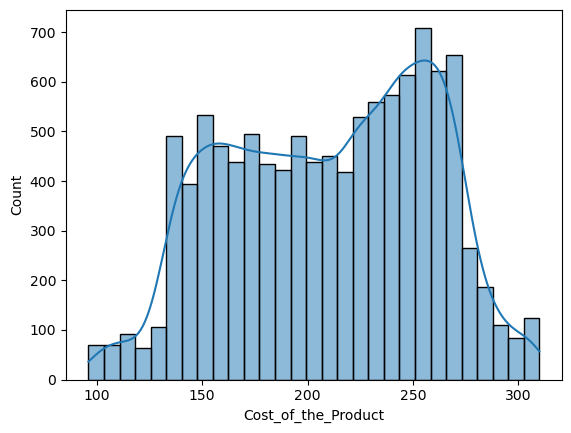

In [22]:
sns.histplot(df['Cost_of_the_Product'], kde=True)
plt.show()

In [23]:
df['Cost_of_the_Product'].fillna(df['Cost_of_the_Product'].median(), inplace=True)

C:\Users\sahoo\AppData\Local\Temp\ipykernel_9220\3413087764.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cost_of_the_Product'].fillna(df['Cost_of_the_Product'].median(), inplace=True)


In [24]:
df.notnull().sum()

ID                     10999
Warehouse_block        10999
Mode_of_Shipment       10999
Customer_care_calls    10999
Customer_rating        10999
Cost_of_the_Product    10999
Prior_purchases        10999
Product_importance     10845
Gender                 10999
Discount_offered       10999
Weight_in_gms          10860
Reached.on.Time_Y.N    10999
dtype: int64

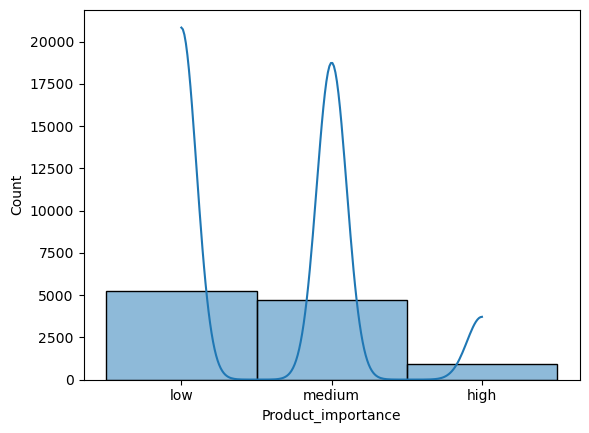

In [25]:
sns.histplot(df['Product_importance'], kde=True)
plt.show()

In [26]:
df['Product_importance'].fillna(df['Product_importance'].mode()[0], inplace=True)

C:\Users\sahoo\AppData\Local\Temp\ipykernel_9220\3811469615.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product_importance'].fillna(df['Product_importance'].mode()[0], inplace=True)


In [27]:
df.notnull().sum()

ID                     10999
Warehouse_block        10999
Mode_of_Shipment       10999
Customer_care_calls    10999
Customer_rating        10999
Cost_of_the_Product    10999
Prior_purchases        10999
Product_importance     10999
Gender                 10999
Discount_offered       10999
Weight_in_gms          10860
Reached.on.Time_Y.N    10999
dtype: int64

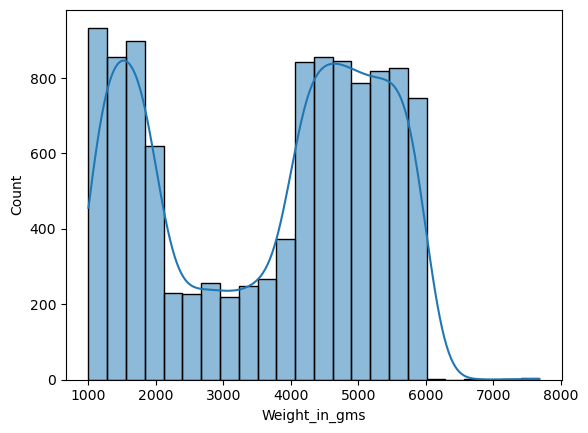

In [28]:
sns.histplot(df['Weight_in_gms'], kde=True)
plt.show()

In [29]:
df['Weight_in_gms'].fillna(df['Weight_in_gms'].median(), inplace=True)

C:\Users\sahoo\AppData\Local\Temp\ipykernel_9220\717156140.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weight_in_gms'].fillna(df['Weight_in_gms'].median(), inplace=True)


In [35]:
df.describe(include='all')

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999,10999,10999.000000,10999.000000,10999.000000,10999.000000,10999,10999,10999.000000,10999.000000,10999.000000
unique,NaN,5,3,NaN,NaN,NaN,NaN,3,2,NaN,NaN,NaN
top,NaN,F,Ship,NaN,NaN,NaN,NaN,low,F,NaN,NaN,NaN
freq,NaN,3666,7462,NaN,NaN,NaN,NaN,5371,5545,NaN,NaN,NaN
mean,5500.00000,NaN,NaN,4.054459,2.990545,210.228293,3.567597,NaN,NaN,13.373216,3648.185881,0.596691
std,3175.28214,NaN,NaN,1.141490,1.413603,47.850315,1.522860,NaN,NaN,16.205527,1625.735062,0.490584
min,1.00000,NaN,NaN,2.000000,1.000000,96.000000,2.000000,NaN,NaN,1.000000,1001.000000,0.000000
25%,2750.50000,NaN,NaN,3.000000,2.000000,170.000000,3.000000,NaN,NaN,4.000000,1854.500000,0.000000
50%,5500.00000,NaN,NaN,4.000000,3.000000,214.000000,3.000000,NaN,NaN,7.000000,4157.500000,1.000000
75%,8249.50000,NaN,NaN,5.000000,4.000000,251.000000,4.000000,NaN,NaN,10.000000,5042.000000,1.000000


Univariate Analysis

In [11]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [13]:
numerical_features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms']

In [36]:
categorial_features = ['Customer_care_calls', 'Customer_rating', 'Prior_purchases', 'Product_importance', 'Mode_of_Shipment', 'Gender']

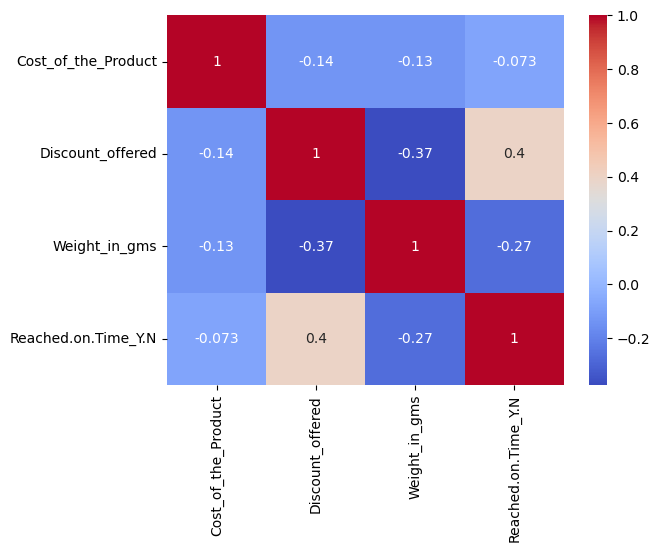

In [37]:
sns.heatmap(df[numerical_features + ['Reached.on.Time_Y.N']].corr(), annot=True, cmap='coolwarm')
plt.show()

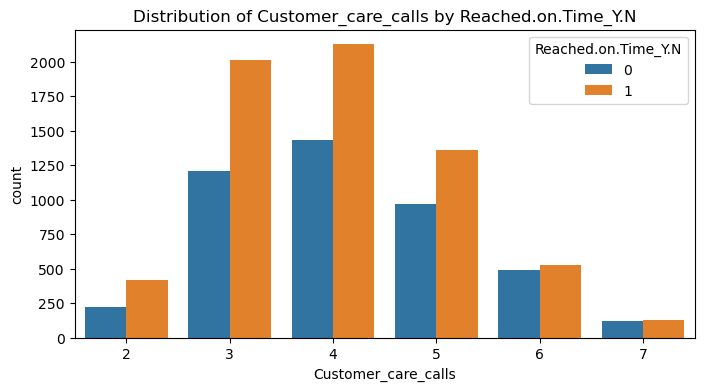

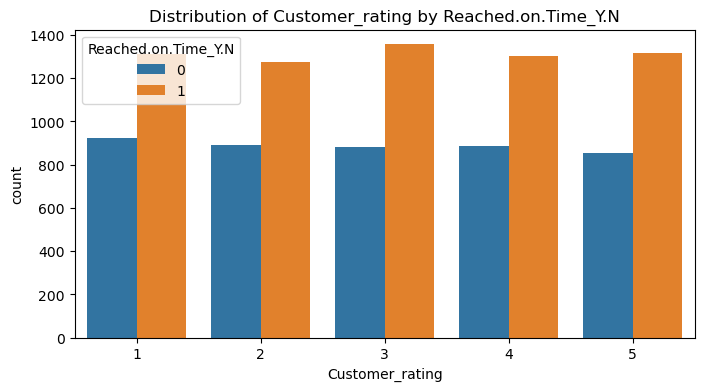

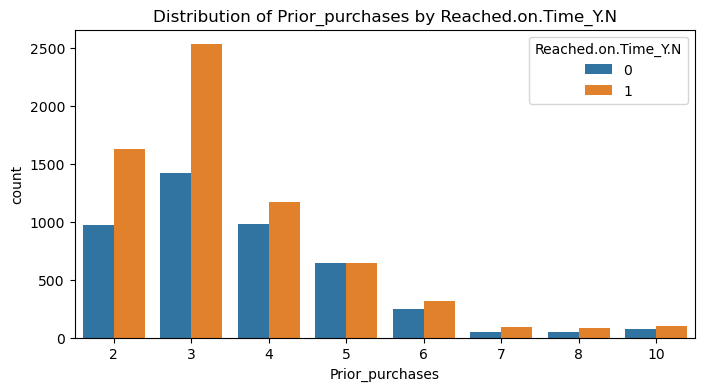

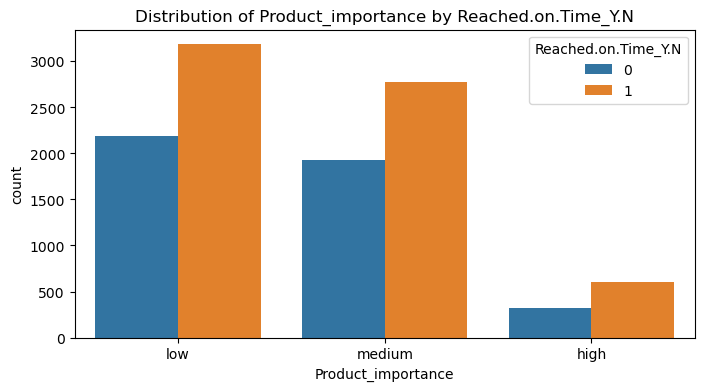

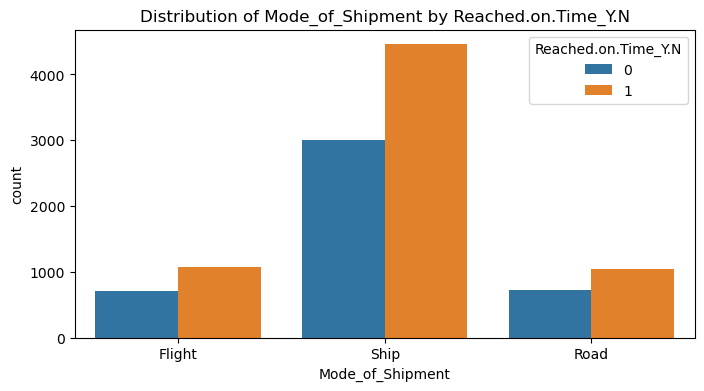

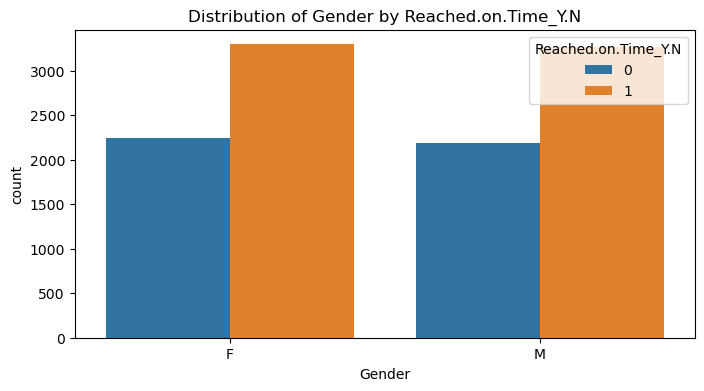

In [38]:
for feature in categorial_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=feature, hue='Reached.on.Time_Y.N')
    plt.title(f'Distribution of {feature} by Reached.on.Time_Y.N')
    plt.show()

Model Build and Training

In [40]:
!pip install category_encoders

In [41]:
import category_encoders as ce
encoder = ce.TargetEncoder(cols=categorial_features)
df_encoded = encoder.fit_transform(df[categorial_features + ['Reached.on.Time_Y.N']], df['Reached.on.Time_Y.N'])
df_encoded.head()

,Customer_care_calls,Customer_rating,Prior_purchases,Product_importance,Mode_of_Shipment,Gender,Reached.on.Time_Y.N
0,0.597695,0.587991,0.640708,0.592813,0.601576,0.594409,1
1,0.597695,0.606633,0.625240,0.592813,0.601576,0.599010,1
2,0.652038,0.587991,0.543387,0.592813,0.601576,0.599010,1
3,0.625117,0.606074,0.543387,0.590251,0.601576,0.599010,1
4,0.652038,0.587991,0.640708,0.590251,0.601576,0.594409,1


In [51]:
df_dummy = pd.get_dummies(df[categorial_features], drop_first=True, dtype=int)

In [52]:
df_dummy.head()

,Customer_care_calls,Customer_rating,Prior_purchases,Product_importance_low,Product_importance_medium,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Gender_M
0,4,2,3,1,0,0,0,0
1,4,5,2,1,0,0,0,1
2,2,2,4,1,0,0,0,1
3,3,3,4,0,1,0,0,1
4,2,2,3,0,1,0,0,0


In [53]:
x = df[numerical_features].join(df_dummy)
y = df['Reached.on.Time_Y.N']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.58      0.70      0.63       895
           1       0.76      0.65      0.70      1305

    accuracy                           0.67      2200
   macro avg       0.67      0.68      0.67      2200
weighted avg       0.69      0.67      0.67      2200

[[628 267]
 [458 847]]


In [78]:
y_test.value_counts()

Reached.on.Time_Y.N
1    1305
0     895
Name: count, dtype: int64

In [84]:
pd.DataFrame(y_pred).value_counts()

0
1    1114
0    1086
Name: count, dtype: int64

In [54]:
# Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, verbose=2)
grid_search.fit(x_train, y_train)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(x_test)
print(classification_report(y_test, y_pred_best))


Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END max_depth=None, max_features=auto, min_samples_leaf=1, min_samples_split=5,

c:\Users\sahoo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
72 fits failed out of a total of 144.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
72 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\sahoo\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sahoo\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\sahoo\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
   

              precision    recall  f1-score   support

           0       0.58      0.87      0.69       895
           1       0.86      0.56      0.68      1305

    accuracy                           0.69      2200
   macro avg       0.72      0.72      0.69      2200
weighted avg       0.75      0.69      0.69      2200



In [85]:
confusion_matrix(y_test, y_pred_best)

array([[776, 119],
       [569, 736]])

In [77]:
#Threshold moving
y_probs = best_model.predict_proba(x_test)[:, 1] # Probabilities for the positive class
threshold = 0.7
y_pred_threshold = (y_probs > threshold).astype(int)
print(classification_report(y_test, y_pred_threshold))
print(confusion_matrix(y_test, y_pred_threshold))


              precision    recall  f1-score   support

           0       0.46      0.01      0.03       895
           1       0.59      0.99      0.74      1305

    accuracy                           0.59      2200
   macro avg       0.53      0.50      0.38      2200
weighted avg       0.54      0.59      0.45      2200

[[  12  883]
 [  14 1291]]


c:\Users\sahoo\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
